# **Mount Drive**

# **Load Data**

In [ ]:
import pandas as pd
ffail = '<DATA_ROOT>/crop_failure_modified/crops_failure_0595_20240221.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])

cond1 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond1]
df_fail.loc[:,'fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]

cols = ['FIPS', 'Crop', 'Irrigation Practice', 'year', 'fail_share']

df_fail = df_fail[cols]
df_fail.groupby('Irrigation Practice').count()

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
  detrended_yield = np.zeros(len(yield_series))
  if len(yield_series) > 2:
    detrended_yield = detrend(yield_series)
  return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)
dfy['d_yield_standard'] = dfy['detrended_yield'] / (dfy['value_yield'] - dfy['detrended_yield'])

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])

cols = ['FIPS','commodity_desc','prodn_practice_desc','year','d_yield_standard']
df_yield = dfy[cols]
condy = df_yield.year > 2008
df_yield = df_yield[condy]
df_yield
# df_yield.groupby('prodn_practice_desc').count()

In [ ]:
from glob import glob
import pandas as pd
in_path = '<DATA_ROOT>/SVI_weightedCrop_Final/*.csv'
files = glob(in_path)

list_df = []
for f in files:
  crop = f.split('/')[-1].split('.')[0][4:]
  # print(crop)
  dfi = pd.read_csv(f).copy()
  dfi['EPL_PCI'] = dfi['EPL_PCI'].fillna(dfi['EPL_HBURD'])
  dfi = dfi.drop(columns=['EPL_HBURD' ,	'EPL_UNINSUR'])
  dfi['Crop'] = crop
  list_df.append(dfi)

df_svi = pd.concat(list_df,ignore_index=True)
df_svi = df_svi.set_index(['STCNTY','YEAR','Crop']).dropna(how='all').reset_index()
df_svi = df_svi.rename(columns={'STCNTY':'FIPS','YEAR':'year'})
df_svi

In [ ]:
import pandas as pd
import numpy as np
fpath_water = '<DATA_ROOT>/WaterUsage/WaterUse_crop_v3.csv'
dfw = pd.read_csv(fpath_water).rename(columns={'Year':'year'})
dfw = dfw[['FIPS','IR-WGWFr','IR-WSWFr','IR-WFrTo','IR-IrTot','year']]
dfw['IR-WGWFr'] = pd.to_numeric(dfw['IR-WGWFr'], errors='coerce')
dfw['IR-WSWFr'] = pd.to_numeric(dfw['IR-WSWFr'], errors='coerce')
dfw['IR-IrTot'] = pd.to_numeric(dfw['IR-IrTot'], errors='coerce')
dfw = dfw[dfw['IR-IrTot'] > 0]
dfw.loc[:,'wu_ratio'] = (dfw['IR-WGWFr'] > dfw['IR-WSWFr']).astype(int)
dfw.loc[:,'gwu_rate'] = dfw['IR-WGWFr'] / dfw['IR-IrTot']
dfw.loc[:,'swu_rate'] = dfw['IR-WSWFr'] / dfw['IR-IrTot']
formatted_numbers = [str(n).zfill(5) for n in dfw['FIPS'].values]
dfw['FIPS'] = formatted_numbers
dfw = dfw[['FIPS','year','gwu_rate','swu_rate']]
dfw['FIPS'] = dfw['FIPS'].astype(int)
dfw

,FIPS,year,gwu_rate,swu_rate
0,1001,2009,1.610738,0.255034
1,1003,2009,2.236618,0.428832
2,1005,2009,0.166667,0.498148
3,1007,2009,0.214286,0.428571
4,1009,2009,0.508475,0.779661
...,...,...,...,...
46609,56037,2023,0.416110,3.546957
46610,56039,2023,0.000000,6.989101
46611,56041,2023,0.573282,4.887083
46612,56043,2023,0.207130,6.698673


In [ ]:
finsure = '<DATA_ROOT>/InsuranceData/InsuranceData.csv'
df_insure = pd.read_csv(finsure)
df_insure['FIPS'] = df_insure['State_Code'] * 1000 + df_insure['County_Code']
cols = ['FIPS', 'Commodity_Name', 'Year_Identifier', 'Liability','Subsidy']
df_insure = df_insure[cols]
df_insure = df_insure.rename(columns={'Commodity_Name':'Crop','Year_Identifier':'year'})
df_insure = df_insure.groupby(['FIPS','Crop','year']).sum().reset_index()
df_insure

<ipython-input-168-cf3af6dd6380>:2: DtypeWarning: Columns (8,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_insure = pd.read_csv(finsure)


,FIPS,Crop,year,Liability,Subsidy
0,1001,CORN,2008,15769.0,3609.0
1,1001,CORN,2009,41069.5,9149.0
2,1001,CORN,2010,6186.0,1217.0
3,1001,CORN,2011,4436.0,402.0
4,1001,CORN,2012,903.0,166.0
...,...,...,...,...,...
106258,56045,WHEAT,2013,27272.0,2772.0
106259,56045,WHEAT,2014,17464.0,2350.0
106260,56045,WHEAT,2015,16345.0,2497.0
106261,56045,WHEAT,2016,32430.0,4744.0


In [ ]:
fcold = '<DATA_ROOT>/ClimateIndex/ColdSpell.csv'
df_cold = pd.read_csv(fcold)
cols = ['FIPS','Year','Thr-2','Thr-1','Thr0']
df_cold = df_cold[cols]
df_cold = df_cold.dropna(subset=['FIPS', 'Year'])
df_cold['FIPS'] = df_cold['FIPS'].astype(int)
df_cold['Year'] = df_cold['Year'].astype(int)
df_cold = df_cold.rename(columns={'Year':'year'})

In [ ]:
fdrought = '<DATA_ROOT>/ClimateIndex/list_droughtFeatures.csv'
df_drought = pd.read_csv(fdrought)
df_drought = df_drought.dropna(subset=['Fips', 'Year'])
df_drought['Fips'] = df_drought['Fips'].astype(int)
df_drought['Year'] = df_drought['Year'].astype(int)
df_drought = df_drought.rename(columns={'Fips':'FIPS'})
df_drought = df_drought.rename(columns={'Year':'year'})

In [ ]:
fprcp = '<DATA_ROOT>/ClimateIndex/prcp.csv'
df_prcp = pd.read_csv(fprcp)
df_prcp = df_prcp.dropna(subset=['FIPS', 'Year'])
df_prcp['FIPS'] = df_prcp['FIPS'].astype(int)
df_prcp['Year'] = df_prcp['Year'].astype(int)
df_prcp = df_prcp.drop(columns=['State','County'])
df_prcp = df_prcp.rename(columns={'Year':'year'})

In [ ]:
fvpd = '<DATA_ROOT>/ClimateIndex/vpdfeatures.csv'
df_vpd = pd.read_csv(fvpd)
df_vpd = df_vpd.dropna(subset=['FIPS', 'Year'])
df_vpd['FIPS'] = df_vpd['FIPS'].astype(int)
df_vpd['Year'] = df_vpd['Year'].astype(int)
df_vpd = df_vpd.drop(columns=['State','County'])
df_vpd = df_vpd.rename(columns={'Year':'year'})

<ipython-input-172-772d0bef6f5b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vpd['FIPS'] = df_vpd['FIPS'].astype(int)
<ipython-input-172-772d0bef6f5b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vpd['Year'] = df_vpd['Year'].astype(int)


In [ ]:
fwarm = '<DATA_ROOT>/ClimateIndex/WarmSpell.csv'
df_warm = pd.read_csv(fwarm)
df_warm = df_warm.dropna(subset=['FIPS', 'Year'])
df_warm['FIPS'] = df_warm['FIPS'].astype(int)
df_warm['Year'] = df_warm['Year'].astype(int)
df_warm = df_warm.drop(columns=['State','County'])
df_warm = df_warm.rename(columns={'Year':'year'})

# **Merge Data & PreAnalysis**

In [ ]:
# df_fail , df_yield , df_svi , dfw
print(df_fail.columns)
print(dfw.columns)
print(df_insure.columns)
print(df_svi.columns)

print(df_cold.columns)
print(df_drought.columns)
print(df_prcp.columns)
print(df_vpd.columns)
print(df_warm.columns)


In [ ]:
cond_irig = df_yield['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
df_yield = df_yield[cond_irig]
df_yield['prodn_practice_desc'] = 'ALL'
df_yield = df_yield.rename(columns={'commodity_desc':'Crop','prodn_practice_desc':'Irrigation Practice'})
df_yield['FIPS'] = df_yield['FIPS'].astype(int)

In [ ]:
df_yield

In [ ]:
df_merge_yield_ins = pd.merge(df_yield,df_insure,on=['FIPS', 'Crop', 'year'],how='outer')
df_merge_yield_ins_svi = pd.merge(df_merge_yield_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer')
df_merge_yield_ins_svi_gwu = pd.merge(df_merge_yield_ins_svi,dfw,on=['FIPS', 'year'],how='outer')

df_merge_yield_ins_svi_gwu = df_merge_yield_ins_svi_gwu.dropna(subset='d_yield_standard')

df_merge_yield_ins_svi_gwu['Liability'] = df_merge_yield_ins_svi_gwu['Liability'].fillna(0)
df_merge_yield_ins_svi_gwu['Subsidy'] = df_merge_yield_ins_svi_gwu['Subsidy'].fillna(0)

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])

df_merge = pd.merge(df_merge_yield_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'])
df_merge

In [ ]:
df_merge_yield = df_merge.copy()
df_merge_yield['Irrigation Practice'].unique()

array(['ALL'], dtype=object)

In [ ]:
import pandas as pd

cond1 = df_merge['Irrigation Practice'] == 'ALL'
df_merge_all = df_merge[cond1]

drop_cols = ['FIPS', 	'Crop', 	'Irrigation Practice', 	'year']
df_merge_all = df_merge_all.drop(columns=drop_cols)

corr_mat_all = df_merge_all.corr()

cond = corr_mat_all.d_yield_standard > 0
corr_all = corr_mat_all[cond].iloc[1:].d_yield_standard


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 8))
plt.plot(corr_all.index, corr_all)
plt.xticks(corr_all.index,rotation=45, ha='right',fontsize=16)
plt.show()

In [ ]:
df_svi = df_svi.drop(columns=['EPL_DISABL'])

In [ ]:
df_merge_crop_ins = pd.merge(df_fail,df_insure,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_crop_ins_svi = pd.merge(df_merge_crop_ins,df_svi,on=['FIPS', 'Crop', 'year'],how='outer',validate='m:1')
df_merge_crop_ins_svi_gwu = pd.merge(df_merge_crop_ins_svi,dfw,on=['FIPS', 'year'],how='outer',validate='m:1')
# df_merge_crop_ins_svi_gwu

df_merge_crop_ins_svi_gwu = df_merge_crop_ins_svi_gwu.dropna(subset='fail_share')
condy = df_merge_crop_ins_svi_gwu.year < 2023
df_merge_crop_ins_svi_gwu = df_merge_crop_ins_svi_gwu[condy]

df_merge_crop_ins_svi_gwu['Liability'] = df_merge_crop_ins_svi_gwu['Liability'].fillna(0)
df_merge_crop_ins_svi_gwu['Subsidy'] = df_merge_crop_ins_svi_gwu['Subsidy'].fillna(0)
# df_merge_crop_ins_svi_gwu

df_merge_clim = pd.merge(df_cold,df_drought,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_prcp,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_vpd,on=['FIPS', 'year'])
df_merge_clim = pd.merge(df_merge_clim,df_warm,on=['FIPS', 'year'])
# df_merge_clim

df_merge = pd.merge(df_merge_crop_ins_svi_gwu,df_merge_clim,on=['FIPS', 'year'],validate='m:1')
df_merge

In [ ]:
# import pandas as pd
# nan_count = df_merge[df_merge.fail_share>0].isna().sum(axis=0)
# nan_count.to_frame()

# import pandas as pd
# cols = ['FIPS', 'Crop', 'year', 'fail_share','gwu_rate', 'swu_rate']
# temp =  df_merge[cols]
# nan_rows = temp[temp.isna().any(axis=1)]
# nan_rows[nan_rows.fail_share>0]

In [ ]:
cond1 = df_merge['Irrigation Practice'] == 'ALL'
df_merge_fail = df_merge[cond1]

In [ ]:
import pandas as pd

cond1 = df_merge['Irrigation Practice'] == 'ALL'
df_merge_all = df_merge[cond1]

cond2 = df_merge['Irrigation Practice'] == 'N'
df_merge_nir = df_merge[cond2]

cond3 = df_merge['Irrigation Practice'] == 'I'
df_merge_ir = df_merge[cond3]

drop_cols = ['FIPS', 	'Crop', 	'Irrigation Practice', 	'year']
df_merge_all = df_merge_all.drop(columns=drop_cols)
df_merge_nir = df_merge_nir.drop(columns=drop_cols)
df_merge_ir = df_merge_ir.drop(columns=drop_cols)

corr_mat_all = df_merge_all.corr()
corr_mat_nir = df_merge_nir.corr()
df_merge_ir = df_merge_ir.corr()

cond = corr_mat_all.fail_share > 0
corr_all = corr_mat_all[cond].iloc[1:].fail_share

cond = corr_mat_nir.fail_share > 0
corr_nir = corr_mat_nir[cond].iloc[1:].fail_share

cond = corr_mat_nir.fail_share > 0
corr_ir = df_merge_ir[cond].iloc[1:].fail_share

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = corr_mat_all
# correlation_matrix.to_csv('<DATA_ROOT>/MachineLearning/failShare_All_Corr_Heatmap.csv')
# Create heatmap
plt.figure(figsize=(30, 24))
sns.heatmap(correlation_matrix, cmap='coolwarm')
# plt.xticks(correlation_matrix.index, rotation=45, ha='right')
plt.title('Correlation Heatmap Failure Share & Deriving Factors - Irrigation Type: All')
# plt.savefig('<DATA_ROOT>/MachineLearning/failShare_All_Corr_Heatmap.jpg')

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# plt.figure(figsize=(30, 8))
# plt.plot(corr_all.index, corr_all)
# plt.xticks(corr_all.index,rotation=45, ha='right',fontsize=16)
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# plt.figure(figsize=(30, 8))
# plt.plot(corr_nir.index, corr_nir)
# plt.xticks(corr_nir.index,rotation=45, ha='right',fontsize=16)
# plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# plt.figure(figsize=(30, 8))
# plt.plot(corr_ir.index, corr_ir)
# plt.xticks(corr_ir.index,rotation=45, ha='right',fontsize=16)
# plt.show()

# **Machine Learning**

In [ ]:
# df_merge = df_merge.drop(columns=['Unnamed: 0'])
# df_merge.to_csv('<DATA_ROOT>/MachineLearning/yield_ML_merge.csv',index=False)
import pandas as pd
df_merge = pd.read_csv('<DATA_ROOT>/MachineLearning/yield_ML_merge.csv')
df_merge

In [ ]:
cond1 = df_merge['Irrigation Practice'] == 'ALL'
df_merge_all = df_merge[cond1]

# cond2 = df_merge['Irrigation Practice'] == 'N'
# df_merge_nir = df_merge[cond2]

# cond3 = df_merge['Irrigation Practice'] == 'I'
# df_merge_ir = df_merge[cond3]

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'SOYBEANS'
df = df_merge_all.drop(columns=['FIPS','Crop','Irrigation Practice','year'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'CORN'
df = df_merge_all.drop(columns=['FIPS','Crop','Irrigation Practice','year'])
scaler = MinMaxScaler()
scaler.fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)
df_scaled


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = df_scaled
X = df.drop(columns=['d_yield_standard'])
y = df['d_yield_standard']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameters
params = {
    'objective': 'reg:squarederror',  # Regression task
    'tree_method':'hist',
    'learning_rate': 0.03,
    'n_estimators': 750,
    'max_depth': 12,
    'min_child_weight': 4,
    'subsample': 0.7,
    'colsample_bytree': 0.75,
    'colsample_bylevel': 0.8,
}

xg_reg = xgb.XGBRegressor(**params)
xg_reg.fit(X_train, y_train)
y_pred = xg_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)


Mean Squared Error: 0.408041011893491
R-squared: 0.6018895074199322


# **ML tuning**

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

def random_search_tuning(y , x):

    # define the train set and test set
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)
    print("Shapes - X_train: ", x_train.shape,
          ", X_val: ", x_val.shape, ", y_train: ",
          y_train.shape, ", y_val: ", y_val.shape)

    params = {'max_depth': list(np.arange(8,21,2)),
              'learning_rate': [0.01, 0.02, 0.03, 0.001, 0.005],
              'subsample': np.arange(0.1, 0.8, 0.1),
              'colsample_bytree': np.arange(0.5, 1.0, 0.05),
              'colsample_bylevel': np.arange(0.3, 1.0, 0.05),
              'n_estimators': [250, 500, 750, 1000, 1250]
              }

    xg_reg = xgb.XGBRegressor(objective="reg:squarederror", tree_method='hist')

    # reg = RandomizedSearchCV(estimator=xg_reg,
    #                          param_distributions=params,
    #                          scoring='neg_mean_squared_error',
    #                          n_iter=25,
    #                          n_jobs=4,
    #                          verbose=1)

    reg = GridSearchCV(estimator=xg_reg,
                       param_grid=params,
                       cv=10,
                       scoring='neg_mean_squared_error',
                       n_jobs=4,
                       verbose=1)

    # Train the model
    reg.fit(x_train, y_train)
    y_pred = reg.predict(x_val)

    r2 = r2_score(y_val, y_pred)
    print("R-squared:", r2)

    best_combination = reg.best_params_

    return best_combination

if __name__ == '__main__':

  df = df_scaled
  X = df.drop(columns=['d_yield_standard'])
  y = df['d_yield_standard']

  best_params = random_search_tuning( y , X)

  print("Best hyperparameter combination: ", best_params)


import pickle
with open('<DATA_ROOT>/MachineLearning/dict_bestparams_grid_search.pkl', 'wb') as f:
    pickle.dump(best_params, f)

In [ ]:
best_params

# **Failure & Yield Analysis**

In [ ]:
# df_merge_yield
# df_merge_fail

In [ ]:
cols = ['FIPS','Crop','year','fail_share']
dff = df_merge_fail[cols]
cols = ['FIPS','Crop','year','d_yield_standard']
dfy = df_merge_yield[cols]


In [ ]:
dffy = pd.merge(dff[dff.fail_share>0],dfy,on=['FIPS','Crop','year'])
dffy.year.unique()

In [ ]:
import matplotlib.pyplot as plt
# cond_crop = dffy.Crop == 'CORN'
# condf = dffy.fail_share < 0.3
cond_year = dffy.year == 2010
x = dffy[cond_year]['fail_share']
y = dffy[cond_year]['d_yield_standard']

# Create scatter plot
plt.scatter(x, y, color='blue', alpha=0.5)  # alpha sets transparency

# Add labels and title
plt.xlabel('fail_share')
plt.ylabel('d_yield_standard')
plt.title('Scatter Plot of fail_share vs d_yield_standard')

# Display the plot
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plot data on the first axis
color = 'tab:blue'
ax1.set_xlabel('X-axis Label')
ax1.set_ylabel('fail_share', color=color)
ax1.plot(dffy['fail_share'].iloc[0:200], color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot additional data on the second axis
color = 'tab:red'
ax2.set_ylabel('d_yield_standard', color=color)
ax2.plot(dffy['d_yield_standard'].iloc[0:200], color=color)  # Example plot for demonstration
ax2.tick_params(axis='y', labelcolor=color)

# Add a title
plt.title('Twin Axes Plot')

# Show the plot
plt.show()


# **Classification**

In [ ]:
# df_merge_yield
# df_merge_fail
# cols = ['FIPS','Crop','year','fail_share']
# dffy = pd.merge(df_merge_fail[cols],df_merge_yield,on=['FIPS','Crop','year'])
# dffy['fail_share'] = (dffy.fail_share > 0).astype(int)
# dffy = dffy[dffy.fail_share > 0]
# dffy

In [ ]:
import pandas as pd
# dffy.to_csv('<DATA_ROOT>/MachineLearning/fail_gt0_yield_ML_merge.csv')
dffy = pd.read_csv('<DATA_ROOT>/MachineLearning/fail_gt0_yield_ML_merge.csv')
dffy = dffy.drop(columns=['Unnamed: 0'])

In [ ]:
import numpy as np
bins = list(dffy[dffy.fail_share>0].fail_share.quantile([0.25,0.5,0.75]))
bins = [0] + bins + [1]
labels = list(np.arange(0,4))
dffy['fail_cls'] = dffy.fail_share.to_frame().apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
dffy['fail_cls'] = dffy['fail_cls'].fillna(0)
dffy#[['fail_share','fail_cls']].groupby('fail_cls').count()

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'CORN'
df = dffy.drop(columns=['FIPS','Crop','Irrigation Practice','year','fail_share','fail_cls'])
scaler = MinMaxScaler()
scaler.fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)
df_scaled


In [ ]:
df_scaled

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_scaled.drop(columns=['d_yield_standard'])
y = dffy['fail_cls']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1865)

params = {'max_depth': 5,
          'learning_rate': 0.01,
          'subsample': 0.7,
          'colsample_bytree': 0.75,
          'colsample_bylevel': 0.75,
          'n_estimators': 500
          }

xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)


# make predictions for test data
y_pred = xgb_model.predict(X_test)
predictions = [round(value) for value in y_pred]

# evaluate predictions
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 42.41%


In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X = df_scaled
y = dffy['fail_cls']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define the hyperparameter grid
params = {'max_depth': list(np.arange(8,21,4)),
          'learning_rate': [0.01, 0.02, 0.03],
          'subsample': np.arange(0.2, 0.8, 0.2),
          'colsample_bytree': np.arange(0.5, 1.0, 0.1),
          'colsample_bylevel': np.arange(0.3, 1.0, 0.1),
          'n_estimators': [500, 750, 1000]
          }

# Create the XGBoost model object
xgb_model = xgb.XGBClassifier()

clf = RandomizedSearchCV(estimator=xgb_model,
                         param_distributions=params,
                         scoring='accuracy',
                         cv = 5 ,
                         n_iter=10,
                         n_jobs=4,
                         verbose=1)

# Create the GridSearchCV object
# grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the training data
clf.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", clf.best_params_)
print("Best score: ", clf.best_score_)

y_pred = clf.predict(X_test)
predictions = [round(value) for value in y_pred]

# evaluate predictions
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

X = df_scaled
y = dffy['fail_cls']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameters for XGBoost
params = {
    'objective': 'multi:softmax',  # Multiclass classification
    'num_class': 4,  # Number of classes
    'eval_metric': 'merror'  # Multiclass classification error rate
}

# Define the number of splits for cross-validation
n_splits = 10

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize a list to store accuracy scores for each fold
accuracy_scores = []

# Perform stratified K-fold cross-validation
for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    print(f"Fold {fold}:")

    # Split data into training and validation sets
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Convert data to DMatrix format for XGBoost
    dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
    dval = xgb.DMatrix(X_val_fold, label=y_val_fold)

    # Train the XGBoost model
    bst = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dval, 'validation')],
                    early_stopping_rounds=10, verbose_eval=False)

    # Make predictions on the validation set
    y_pred = bst.predict(dval)

    # Calculate accuracy and store it
    accuracy = accuracy_score(y_val_fold, y_pred)
    accuracy_scores.append(accuracy)

    print(f"Validation Accuracy: {accuracy:.4f}")
    print("---------------------------------------")

# Calculate mean accuracy across all folds
mean_accuracy = np.mean(accuracy_scores)
print(f"Mean Accuracy: {mean_accuracy:.4f}")


In [ ]:
data = {
    'y_test': y_val_fold,
    'y_pred': y_pred
}
df = pd.DataFrame(data)
df[df.y_test>0].sort_values('y_test')

In [ ]:
y_pred

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

# **Classification Failure Share**

In [ ]:
# # df_merge_yield
# # df_merge_fail
# cols = ['FIPS','Crop','year','d_yield_standard']
# dfy = df_merge_yield[cols]
# dffy = pd.merge(df_merge_fail[df_merge_fail.fail_share>0],dfy,on=['FIPS','Crop','year'])
# dffy = dffy.drop(columns='EPL_DISABL')
# dffy = dffy.dropna()
# dffy

In [ ]:
import pandas as pd
# dffy.to_csv('<DATA_ROOT>/MachineLearning/fail_yield_ML_merge_20240221.csv',index=False)
dff = pd.read_csv('<DATA_ROOT>/MachineLearning/fail_yield_ML_merge_20240221.csv')
# dff

In [ ]:
import pandas as pd
# df_merge_fail.to_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge_20240221.csv',index=False)
dff = pd.read_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge_20240221.csv')


In [ ]:
cols = ['FIPS', 'Crop', 'Irrigation Practice', 'year', 'fail_share',
       'Liability', 'Subsidy','RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3','RPL_THEME4','RPL_THEMES',
       'Thr0','spei180d-1', 'spei180d-2','spei270d-1', 'spei270d-2','dpi1', 'dpi5','dpi20','VPD-Mean',
       'VPD-1', 'VPD-2','Thr27', 'Thr30', 'Thr31','Thr33', 'Thr36'] #+ ['d_yield_standard']
dff = dff[cols]

In [ ]:
# dff = dff.drop(columns='EPL_DISABL')
dff = dff.dropna()
dff = dff[dff.fail_share > 0]
print(dff.groupby('Crop').count())
# dff = dff[dff.Crop =='SOYBEANS']


In [ ]:
dff

In [ ]:
import numpy as np
bins = list(dff[dff.fail_share>0].fail_share.quantile(np.arange(0,0.98,0.3333)))
# bins = list(dff[dff.fail_share>0].fail_share.quantile(np.arange(0,1,0.25)))
# bins = list(dff[dff.fail_share>0].fail_share.quantile([0, 0.3333, 0.5, 0.6666]))
bins = bins + [1]
labels = list(np.arange(0,3))
dff['fail_cls'] = dff.fail_share.to_frame().apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
dff['fail_cls'] = dff['fail_cls'].fillna(0)
# dff

In [ ]:
dff_sampled = dff.copy()

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'CORN'
dff_sampled.dropna(inplace=True)

df = dff_sampled.drop(columns=['FIPS','Crop','Irrigation Practice','year','fail_share','fail_cls'])
scaler = MinMaxScaler()
scaler.fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)
# df_scaled


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_scaled
y = dff_sampled['fail_cls']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=85)

params = {'max_depth': 7,
          'learning_rate': 0.055,
          'subsample': 0.65,
          'colsample_bytree': 0.8,
          'colsample_bylevel': 0.75,
          'n_estimators': 650,
          'booster': 'gbtree',
          'max_leaves':100,
          }

xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)

accuracy_test = accuracy_score(y_test, y_pred)
print("Accuracy_test: %.2f%%" % (accuracy_test * 100.0))
accuracy_train = accuracy_score(y_train, y_pred2)
print("Accuracy_train: %.2f%%" % (accuracy_train * 100.0))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(np.array([cm[0,0],cm[1,1],cm[2,2]])/np.sum(cm,axis=1))

Accuracy_test: 47.17%
Accuracy_train: 99.97%
[0.48623853 0.37096774 0.6       ]


In [ ]:
# SOYBEANS
# test_size=0.1,random_state=85
# params = {'max_depth': 7,
#           'learning_rate': 0.055,
#           'subsample': 0.65,
#           'colsample_bytree': 0.75,
#           'colsample_bylevel': 0.75,
#           'n_estimators': 650,
#           'booster': 'gbtree',
#           'max_leaves':100,
#           }
# Accuracy_test: 49.37%
# Accuracy_train: 99.97%
# [0.51376147 0.41935484 0.6       ]

# CORN
# test_size=0.1,random_state=85
# params = {'max_depth': 7,
#           'learning_rate': 0.05,
#           'subsample': 0.8,
#           'colsample_bytree': 0.75,
#           'colsample_bylevel': 0.75,
#           'n_estimators': 650,
#           'booster': 'gbtree',
#           'max_leaves':100,
#           }
# Accuracy_test: 56.66%
# Accuracy_train: 99.49%
# [0.58173077 0.44751381 0.65989848]

# WHEAT
# test_size=0.1,random_state=100
# params = {'max_depth': 7,
#           'learning_rate': 0.007,
#           'subsample': 0.8,
#           'colsample_bytree': 0.55,
#           'colsample_bylevel': 0.7,
#           'n_estimators': 650,
#           'booster': 'gbtree',
#           'max_leaves':100,
#           }
# Accuracy_test: 52.31%
# Accuracy_train: 83.42%
# [0.62393162 0.38910506 0.56343284]



[0.62393162 0.38910506 0.56343284]


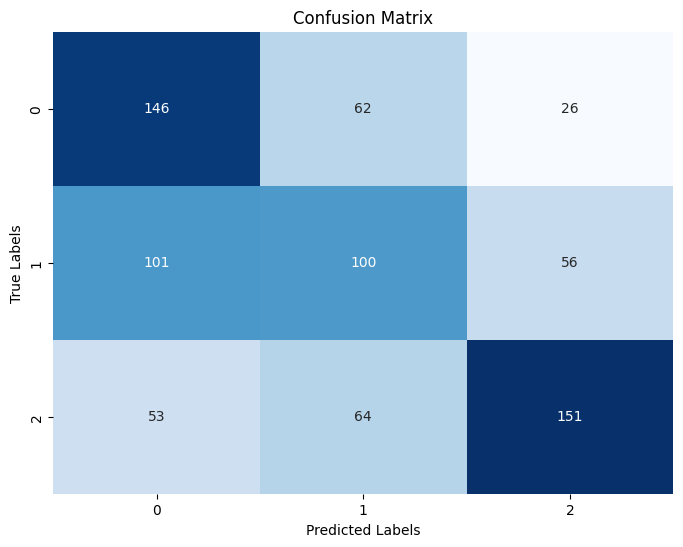

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_true are the true labels and y_pred are the predicted labels
# Replace y_true and y_pred with your actual true and predicted labels

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)
# cm = confusion_matrix(y_train, y_pred2)
print(np.array([cm[0,0],cm[1,1],cm[2,2]])/np.sum(cm,axis=1))
# Display confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


array([0.61057692, 0.32596685, 0.73604061])

In [ ]:
# import xgboost as xgb
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import r2_score
# from sklearn.metrics import accuracy_score

# X = df_scaled
# y = dff_sampled['fail_cls']

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# # Define the hyperparameter grid
# params = {'max_depth': list(np.arange(1,15,1)),
#           'learning_rate': list(np.arange(0.03,0.09,0.01)),
#           'subsample': np.arange(0.5, 0.71, 0.02),
#           'colsample_bytree': np.arange(0.4, 0.61, 0.02),
#           'colsample_bylevel': np.arange(0.8, 1.2, 0.05),
#           'n_estimators': list(np.arange(100,301,20)),
#           }

# # Create the XGBoost model object
# xgb_model = xgb.XGBClassifier()

# clf = RandomizedSearchCV(estimator=xgb_model,
#                          param_distributions=params,
#                          scoring='accuracy',
#                          cv = 5 ,
#                          n_iter=5,
#                          n_jobs=4,
#                          verbose=1)

# # Create the GridSearchCV object
# # grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy')

# # Fit the GridSearchCV object to the training data
# clf.fit(X_train, y_train)

# # Print the best set of hyperparameters and the corresponding score
# print("Best set of hyperparameters: ", clf.best_params_)
# print("Best score: ", clf.best_score_)

# y_pred = clf.predict(X_test)
# predictions = [round(value) for value in y_pred]

# # evaluate predictions
# accuracy = accuracy_score(y_test, predictions)
# print("Accuracy: %.2f%%" % (accuracy * 100.0))

# import pickle
# with open('<DATA_ROOT>/MachineLearning/dict_best_random_fail_class_all_2.pkl', 'wb') as f:
#     pickle.dump(clf.best_params_, f)

In [ ]:
# params = {'max_depth': list(np.arange(1,41,5)),
#           'learning_rate': [0.001,0.005,0.01,0.02,0.03,0.05,0.1],
#           'subsample': np.arange(0.1, 1.1, 0.1),
#           'colsample_bytree': np.arange(0.1, 1.1, 0.1),
#           'colsample_bylevel': np.arange(0.1, 1.1, 0.1),
#           'n_estimators': list(np.arange(50,1001,50)),
#           }

# params = {'max_depth': list(np.arange(1,15,1)),
#           'learning_rate': list(np.arange(0.03,0.09,0.01)),
#           'subsample': np.arange(0.5, 0.71, 0.02),
#           'colsample_bytree': np.arange(0.4, 0.61, 0.02),
#           'colsample_bylevel': np.arange(0.8, 1.2, 0.05),
#           'n_estimators': list(np.arange(100,301,20)),
#           }
# Accuracy: 32.88%






In [ ]:
# clf.best_params_

{'subsample': 0.52,
 'n_estimators': 140,
 'max_depth': 13,
 'learning_rate': 0.04,
 'colsample_bytree': 0.5800000000000002,
 'colsample_bylevel': 1.0000000000000002}

# **Regression Failure Share**

In [ ]:
import pandas as pd
# df_merge_fail.to_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge.csv',index=False)
dff = pd.read_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge_20240221.csv')
# dff

In [ ]:
cols = ['FIPS', 'Crop', 'Irrigation Practice', 'year', 'fail_share',
       'Liability', 'Subsidy','RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3','RPL_THEME4','RPL_THEMES',
       'Thr0','spei180d-1', 'spei180d-2','spei270d-1', 'spei270d-2','dpi1', 'dpi5','dpi20','VPD-Mean',
       'VPD-1', 'VPD-2','Thr27', 'Thr30', 'Thr31','Thr33', 'Thr36']
dff = dff[cols]

In [ ]:
# dff = dff.drop(columns='EPL_DISABL')
dff = dff.dropna()
dff = dff[dff.fail_share > 0]
dff = dff[dff.Crop =='SOYBEANS']


In [ ]:
dff_sampled = dff.copy()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'SOYBEANS'
df = dff_sampled.drop(columns=['FIPS','Crop','Irrigation Practice','year'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_scaled

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'CORN'
dff_sampled.dropna(inplace=True)

df = dff_sampled.drop(columns=['FIPS','Crop','Irrigation Practice','year'])
scaler = MinMaxScaler()
scaler.fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)
# df_scaled


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['fail_share'])
y = df_scaled['fail_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# params = {'max_depth': 8,
#           'learning_rate': 0.001,
#           'subsample': 0.6,
#           'colsample_bytree': 0.6,
#           'colsample_bylevel': 0.6,
#           'n_estimators': 750
#           }

xgb_model = xgb.XGBRegressor()
xgb_model.fit(X_train, y_train)


# make predictions for test data
y_pred = xgb_model.predict(X_test)
y_pred2 = xgb_model.predict(X_train)
# predictions = [round(value) for value in y_pred]



# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared_test:", r2)

r2 = r2_score(y_train, y_pred2)
print("R-squared_train:", r2)


R-squared_test: 0.01629995652616978
R-squared_train: 0.9960794627288903


In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df_scaled.drop(columns=['fail_share'])
y = df_scaled['fail_share']
# Generate some synthetic data for demonstration

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize the Support Vector Machine Regression model
svm_regressor = SVR(kernel='rbf')  # You can choose different kernels ('linear', 'poly', 'rbf', 'sigmoid', etc.)

# Train the model
svm_regressor.fit(X_train, y_train)



# make predictions for test data
y_pred = svm_regressor.predict(X_test)
y_pred2 = svm_regressor.predict(X_train)
# predictions = [round(value) for value in y_pred]



# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared_test:", r2)

r2 = r2_score(y_train, y_pred2)
print("R-squared_train:", r2)


R-squared_test: 0.05726232795478747
R-squared_train: 0.07136100171876081


In [ ]:
# import xgboost as xgb
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import r2_score
# from sklearn.metrics import accuracy_score

# X = df_scaled
# y = dff_sampled['fail_cls']

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# # Define the hyperparameter grid
# params = {'max_depth': list(np.arange(1,15,1)),
#           'learning_rate': list(np.arange(0.03,0.09,0.01)),
#           'subsample': np.arange(0.5, 0.71, 0.02),
#           'colsample_bytree': np.arange(0.4, 0.61, 0.02),
#           'colsample_bylevel': np.arange(0.8, 1.2, 0.05),
#           'n_estimators': list(np.arange(100,301,20)),
#           }

# # Create the XGBoost model object
# xgb_model = xgb.XGBClassifier()

# clf = RandomizedSearchCV(estimator=xgb_model,
#                          param_distributions=params,
#                          scoring='accuracy',
#                          cv = 5 ,
#                          n_iter=5,
#                          n_jobs=4,
#                          verbose=1)

# # Create the GridSearchCV object
# # grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy')

# # Fit the GridSearchCV object to the training data
# clf.fit(X_train, y_train)

# # Print the best set of hyperparameters and the corresponding score
# print("Best set of hyperparameters: ", clf.best_params_)
# print("Best score: ", clf.best_score_)

# y_pred = clf.predict(X_test)
# predictions = [round(value) for value in y_pred]

# # evaluate predictions
# accuracy = accuracy_score(y_test, predictions)
# print("Accuracy: %.2f%%" % (accuracy * 100.0))

# import pickle
# with open('<DATA_ROOT>/MachineLearning/dict_best_random_fail_class_all_2.pkl', 'wb') as f:
#     pickle.dump(clf.best_params_, f)

In [ ]:
# params = {'max_depth': list(np.arange(1,41,5)),
#           'learning_rate': [0.001,0.005,0.01,0.02,0.03,0.05,0.1],
#           'subsample': np.arange(0.1, 1.1, 0.1),
#           'colsample_bytree': np.arange(0.1, 1.1, 0.1),
#           'colsample_bylevel': np.arange(0.1, 1.1, 0.1),
#           'n_estimators': list(np.arange(50,1001,50)),
#           }

# params = {'max_depth': list(np.arange(1,15,1)),
#           'learning_rate': list(np.arange(0.03,0.09,0.01)),
#           'subsample': np.arange(0.5, 0.71, 0.02),
#           'colsample_bytree': np.arange(0.4, 0.61, 0.02),
#           'colsample_bylevel': np.arange(0.8, 1.2, 0.05),
#           'n_estimators': list(np.arange(100,301,20)),
#           }
# Accuracy: 32.88%






In [ ]:
# clf.best_params_

{'subsample': 0.52,
 'n_estimators': 140,
 'max_depth': 13,
 'learning_rate': 0.04,
 'colsample_bytree': 0.5800000000000002,
 'colsample_bylevel': 1.0000000000000002}

# **Histogram**

In [ ]:
import pandas as pd
# df_merge_fail.to_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge.csv',index=False)
dff = pd.read_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge_20240221.csv')
dff

In [ ]:
dff = dff.drop(columns='EPL_DISABL')
dff = dff.dropna()
dff = dff[dff.fail_share > 0]
dff = dff[dff.Crop =='SOYBEANS']


In [ ]:
import numpy as np
bins = list(dff[dff.fail_share>0].fail_share.quantile(np.arange(0,1.01,0.05)))
# bins = [0] + bins + [1]
# bins = []
labels = list(np.arange(0,20))
dff['fail_cls'] = dff.fail_share.to_frame().apply(lambda x: pd.cut(x, bins=bins, labels=labels), axis=0)
dff['fail_cls'] = dff['fail_cls'].fillna(0)
dff

In [ ]:
dff_sampled = dff.copy()
# dff_sampled.dropna(inplace=True)
dff_sampled

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# condf = df_merge_ir.fail_share > 0
# cond_crop = df_merge_all.Crop == 'CORN'
dff_sampled.dropna(inplace=True)

df = dff_sampled.drop(columns=['FIPS','Crop','Irrigation Practice','year','fail_share'])
scaler = MinMaxScaler()
scaler.fit(df)
df_scaled = pd.DataFrame(scaler.transform(df), columns=df.columns)
df_scaled


Text(0.5, 1.0, 'Histogram of Column')

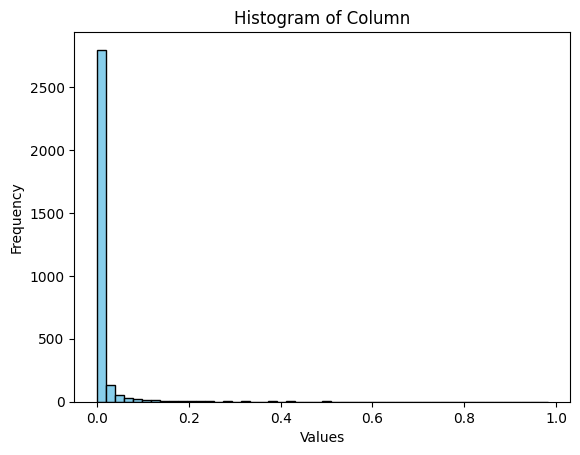

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.hist(dff[dff.fail_share > 0]['fail_share'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Column')

In [ ]:
bins = [0, 0.002, 0.01, 0.05,0.2,1]

In [ ]:
dff[dff.fail_share < 0.2]

# New Section

In [ ]:
import pandas as pd
# df_merge_fail.to_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge.csv',index=False)
dff = pd.read_csv('<DATA_ROOT>/MachineLearning/fail_ML_merge.csv')
dff

In [ ]:
dff = dff.drop(columns='EPL_DISABL')
dff = dff.dropna()
dff = dff[dff.fail_share > 0]
dff = dff[dff.Crop =='SOYBEANS']
